In [1]:
#predictions for target (0=good, 1=bad)
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder

In [2]:
test = pd.read_csv('./application_test.csv')
train = pd.read_csv('./application_train.csv')

In [3]:
col_desc = pd.read_csv('./HomeCredit_columns_description.csv', encoding='cp1252')
col_desc.loc[col_desc['Table'] == 'DAYS_LAST_PHONE_CHANGE']
col_desc = col_desc.dropna()
col_desc

,NumberOfRow,Table,Row,Description
19,application_{train|test}.csv,REGION_POPULATION_RELATIVE,Normalized population of region where client l...,normalized
20,application_{train|test}.csv,DAYS_BIRTH,Client's age in days at the time of application,time only relative to the application
21,application_{train|test}.csv,DAYS_EMPLOYED,How many days before the application the perso...,time only relative to the application
22,application_{train|test}.csv,DAYS_REGISTRATION,How many days before the application did clien...,time only relative to the application
23,application_{train|test}.csv,DAYS_ID_PUBLISH,How many days before the application did clien...,time only relative to the application
36,application_{train|test}.csv,HOUR_APPR_PROCESS_START,Approximately at what hour did the client appl...,rounded
44,application_{train|test}.csv,EXT_SOURCE_1,Normalized score from external data source,normalized
45,application_{train|test}.csv,EXT_SOURCE_2,Normalized score from external data source,normalized
46,application_{train|test}.csv,EXT_SOURCE_3,Normalized score from external data source,normalized
126,bureau.csv,SK_BUREAU_ID,Recoded ID of previous Credit Bureau credit re...,hashed


In [4]:
for col in train:
    if train[col].dtype == 'object':
        print(col)

NAME_CONTRACT_TYPE
CODE_GENDER
FLAG_OWN_CAR
FLAG_OWN_REALTY
NAME_TYPE_SUITE
NAME_INCOME_TYPE
NAME_EDUCATION_TYPE
NAME_FAMILY_STATUS
NAME_HOUSING_TYPE
OCCUPATION_TYPE
WEEKDAY_APPR_PROCESS_START
ORGANIZATION_TYPE
FONDKAPREMONT_MODE
HOUSETYPE_MODE
WALLSMATERIAL_MODE
EMERGENCYSTATE_MODE


<AxesSubplot:>

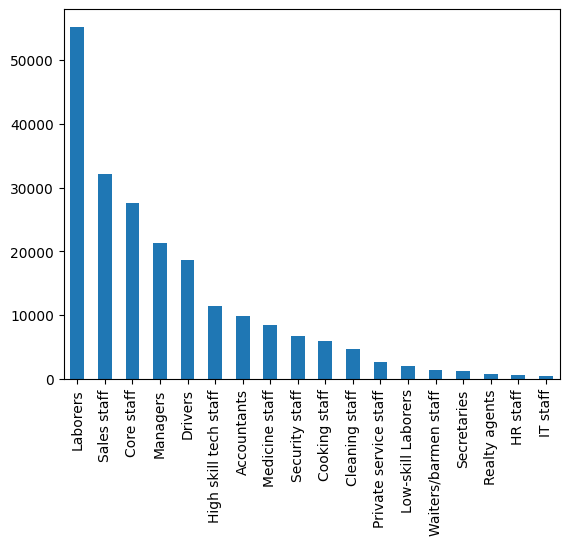

In [5]:
train['OCCUPATION_TYPE'].value_counts().plot.bar()

In [6]:
train['OCCUPATION_TYPE'].value_counts()

Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: OCCUPATION_TYPE, dtype: int64

<AxesSubplot:xlabel='OCCUPATION_TYPE'>

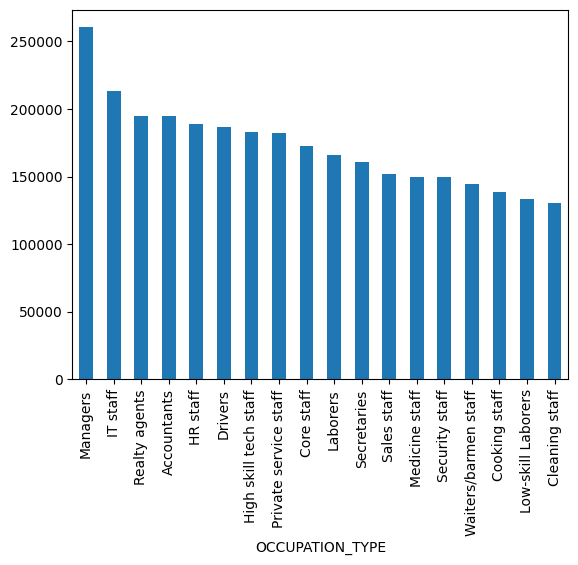

In [7]:
train.groupby(['OCCUPATION_TYPE'])['AMT_INCOME_TOTAL'].mean().sort_values(ascending=False).plot.bar()

<AxesSubplot:xlabel='OCCUPATION_TYPE'>

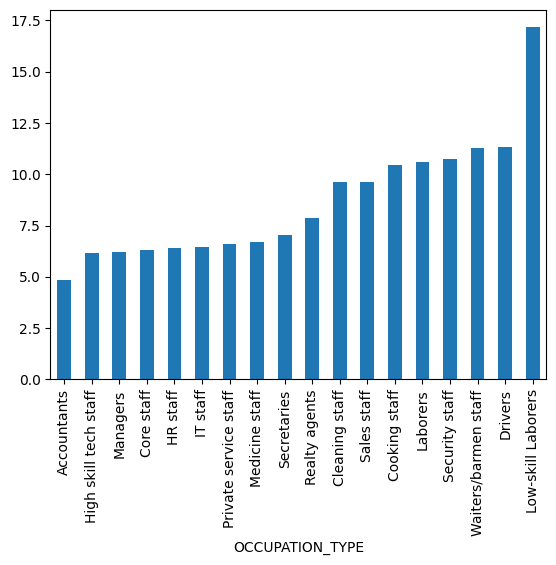

In [24]:
(train.groupby(['OCCUPATION_TYPE'])['TARGET'].mean().sort_values(ascending=True)*100).plot.bar()

<AxesSubplot:xlabel='OCCUPATION_TYPE'>

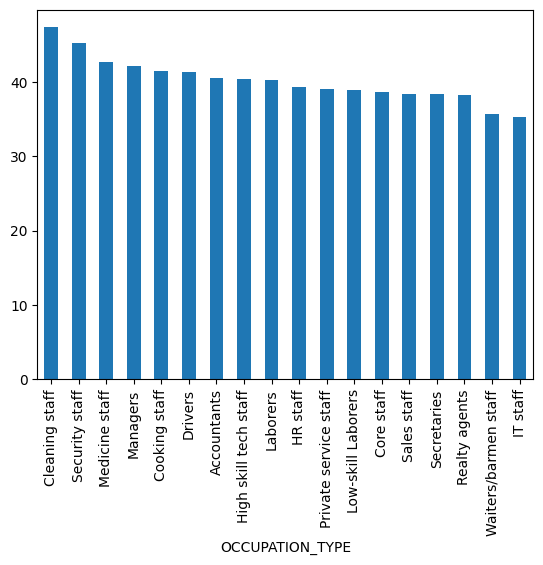

In [8]:
train['DAYS_BIRTH'] = abs(train['DAYS_BIRTH']) / 365
train.groupby(['OCCUPATION_TYPE'])['DAYS_BIRTH'].mean().sort_values(ascending=False).plot.bar()

<AxesSubplot:xlabel='OCCUPATION_TYPE'>

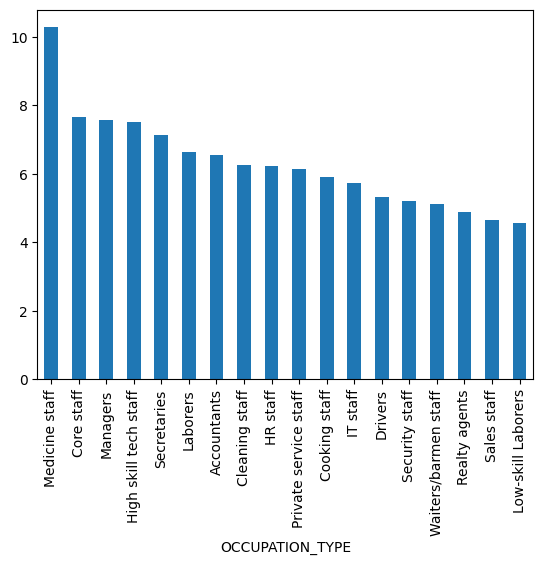

In [9]:
train['DAYS_EMPLOYED'] = abs(train['DAYS_EMPLOYED']) / 365
train.groupby(['OCCUPATION_TYPE'])['DAYS_EMPLOYED'].mean().sort_values(ascending=False).plot.bar()

<AxesSubplot:xlabel='OCCUPATION_TYPE'>

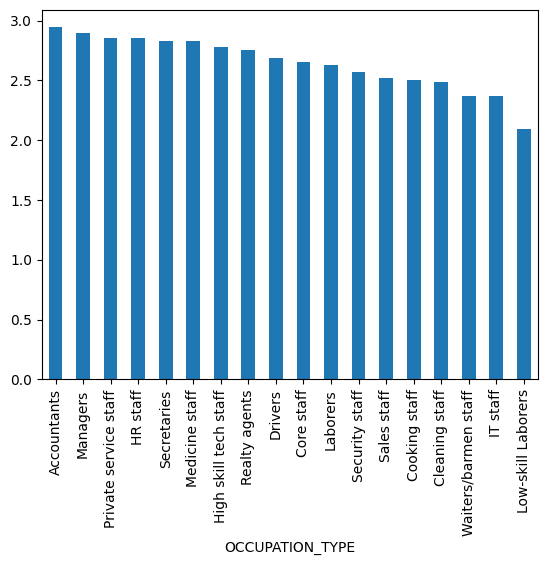

In [10]:
train['DAYS_LAST_PHONE_CHANGE'] = abs(train['DAYS_LAST_PHONE_CHANGE']) / 365
train.groupby(['OCCUPATION_TYPE'])['DAYS_LAST_PHONE_CHANGE'].mean().sort_values(ascending=False).plot.bar()

<AxesSubplot:xlabel='OCCUPATION_TYPE'>

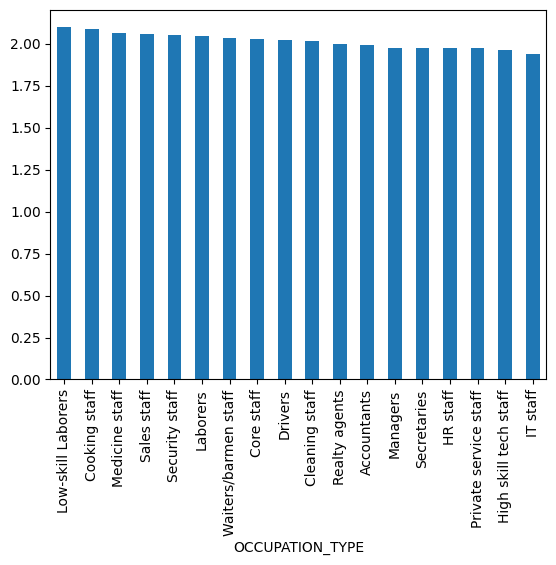

In [11]:
train.groupby(['OCCUPATION_TYPE'])['REGION_RATING_CLIENT_W_CITY'].mean().sort_values(ascending=False).plot.bar()

<AxesSubplot:>

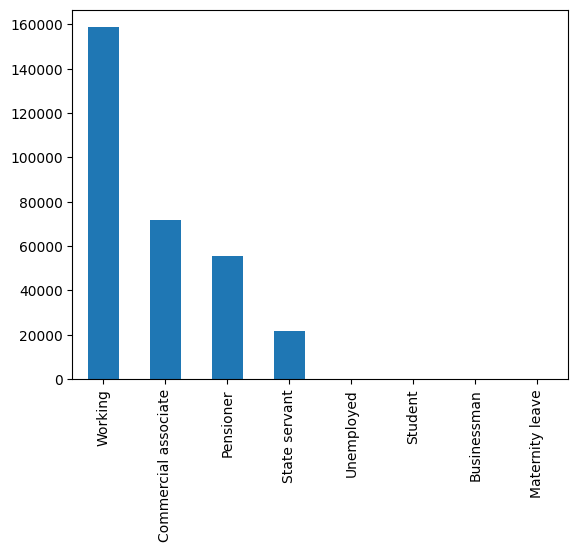

In [12]:
train['NAME_INCOME_TYPE'].value_counts().plot.bar()

<AxesSubplot:>

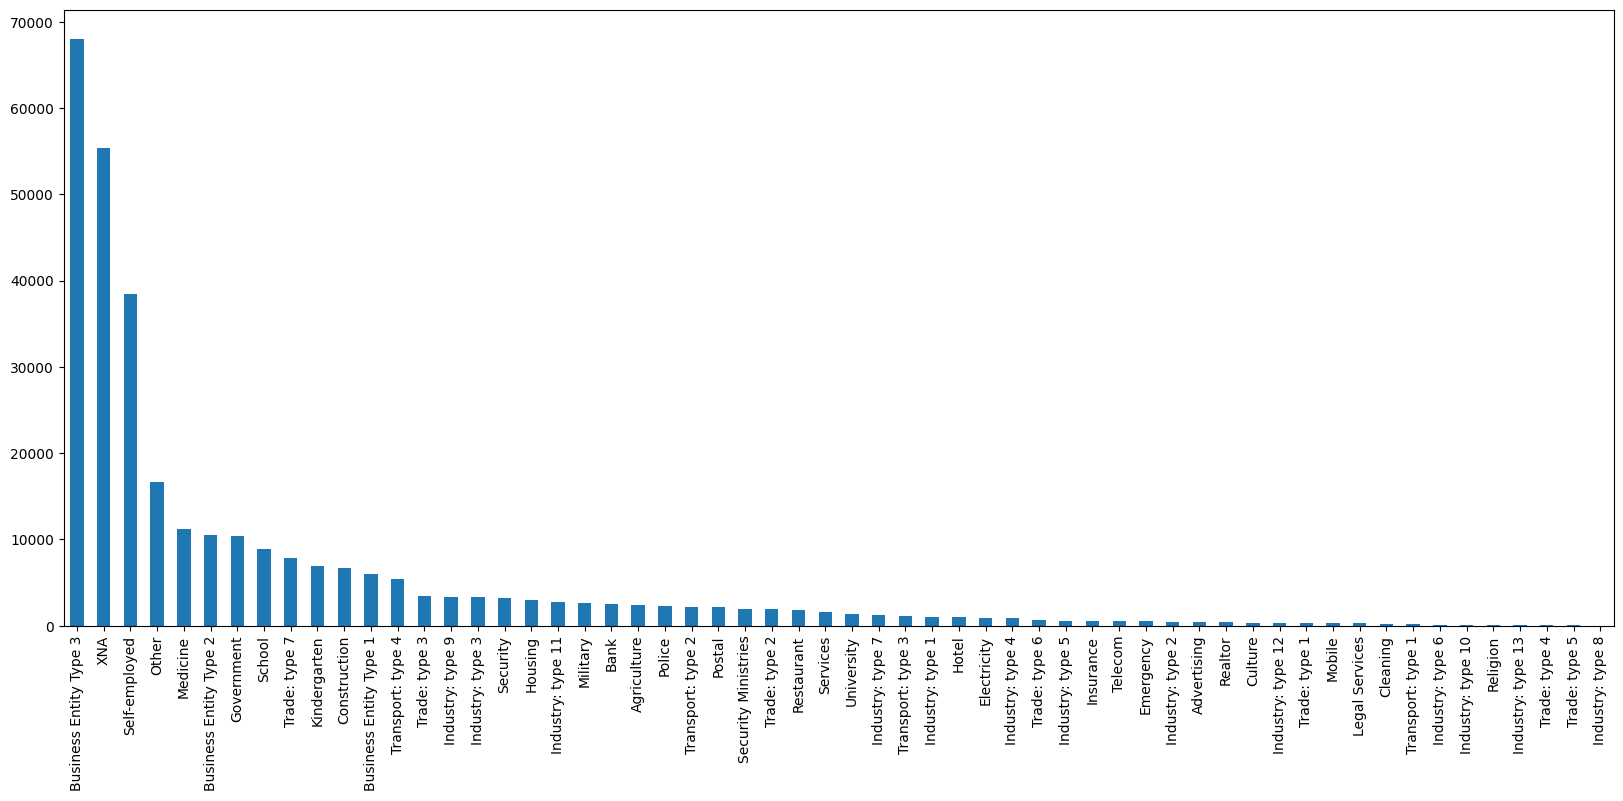

In [13]:
plt.figure(figsize = (20, 8))
train['ORGANIZATION_TYPE'].value_counts().plot.bar()

<AxesSubplot:>

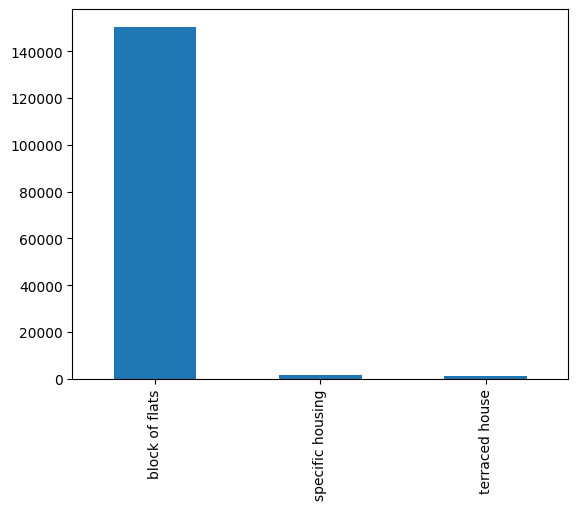

In [14]:
train['HOUSETYPE_MODE'].value_counts().plot.bar()

<AxesSubplot:>

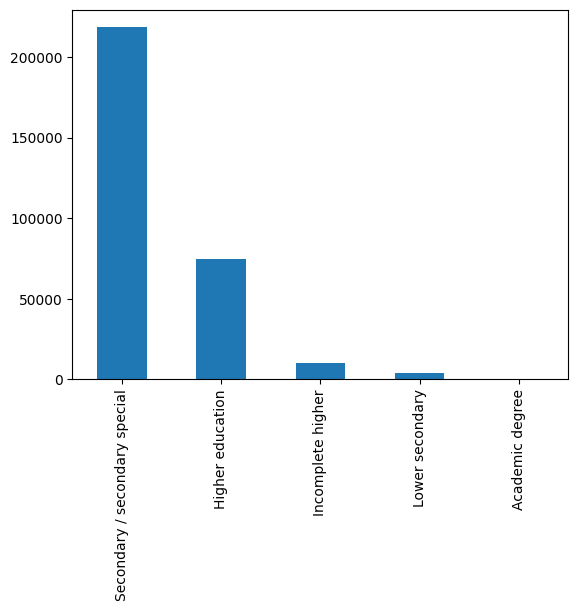

In [15]:
train['NAME_EDUCATION_TYPE'].value_counts().plot.bar()

<AxesSubplot:>

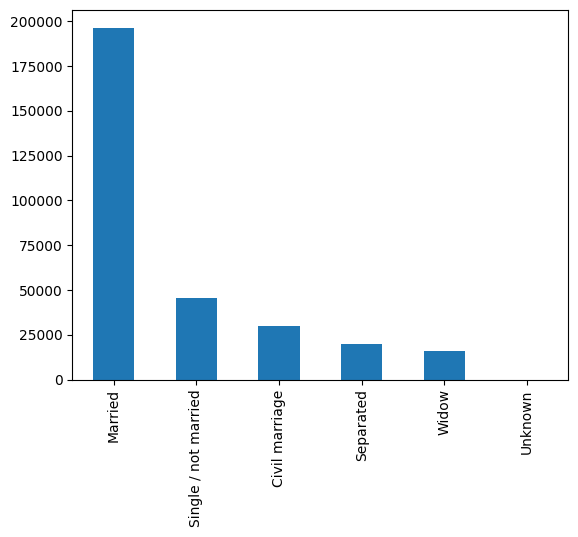

In [16]:
train['NAME_FAMILY_STATUS'].value_counts().plot.bar()

<AxesSubplot:>

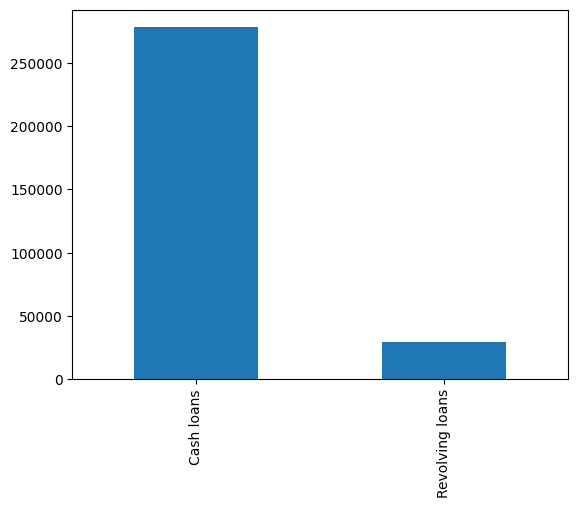

In [17]:
train['NAME_CONTRACT_TYPE'].value_counts().plot.bar()

<AxesSubplot:>

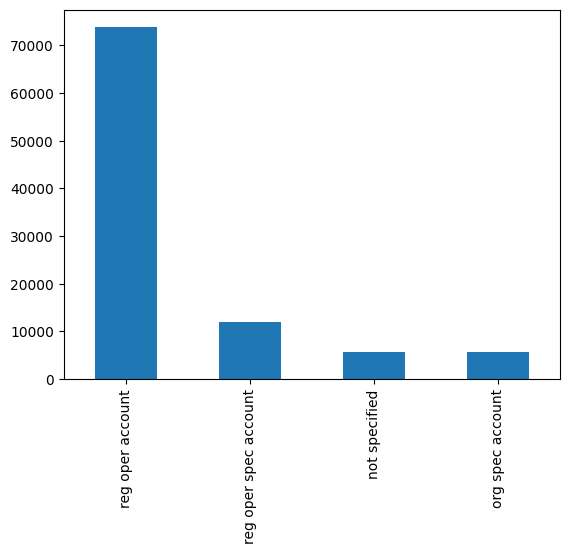

In [18]:
train['FONDKAPREMONT_MODE'].value_counts().plot.bar()

<AxesSubplot:>

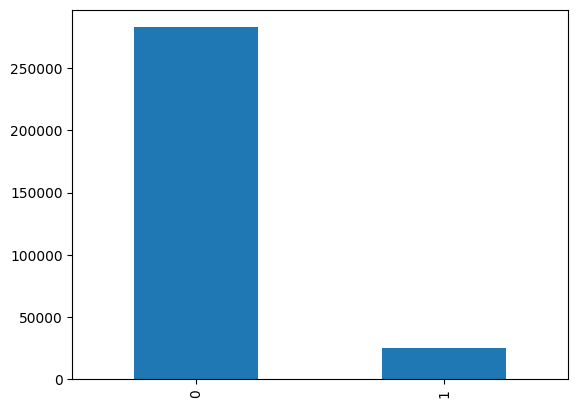

In [19]:
train['TARGET'].value_counts().plot.bar()

<AxesSubplot:xlabel='REGION_RATING_CLIENT_W_CITY'>

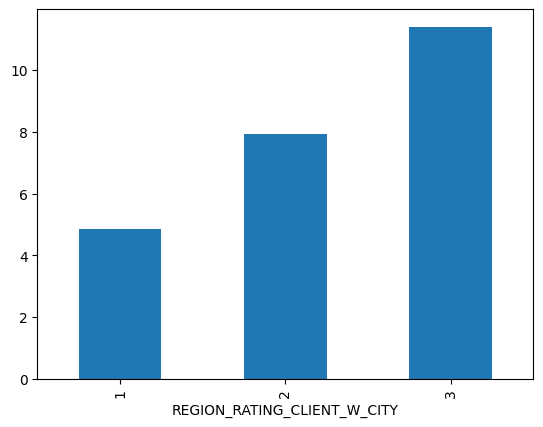

In [26]:
(train.groupby(['REGION_RATING_CLIENT_W_CITY'])['TARGET'].mean()*100).plot.bar()